# SafeCity – Harassment Behavior Score (Pose based)
**Google Colab version.** Pehle: Runtime → Change runtime type → **T4 GPU**.

Image → YOLOv8-Pose (har insaan ke 17 body keypoints, multi-person) → pair features → Random Forest → harassment score (0–1)

**Har cell ko upar se neeche ek ek kar ke chalao (Shift + Enter).**

## Step 1: Libraries install

In [1]:
!pip install -q ultralytics kagglehub
import os
os.makedirs("/content/output", exist_ok=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 731.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 6.4 MB/s eta 0:00:00


## Step 1b: Kaggle se dataset Colab mein download (1.47 GB, ~2-5 min)
Agar login maange to: kaggle.com → Settings → **API → Create New Token** se `kaggle.json` download karo, phir neeche wale `kagglehub.login()` mein username aur key daal do.

In [2]:
import kagglehub
try:
    DATA_ROOT = kagglehub.dataset_download("tasneemhesham/harassment-dataset")
except Exception as e:
    print("Login chahiye:", e)
    kagglehub.login()
    DATA_ROOT = kagglehub.dataset_download("tasneemhesham/harassment-dataset")
print("Dataset path:", DATA_ROOT)

100%|██████████| 1.37G/1.37G [00:16<00:00, 91.1MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/tasneemhesham/harassment-dataset/versions/1


## Step 2: Dataset dhoondo + images ki list banao
Har video-folder se har 5th image (max 100) li ja rahi hai, kyunki lagataar frames taqreeban ek jaise hote hain.

In [3]:
import os, glob, random
import pandas as pd

VIOLENT_DIR = NONVIOLENT_DIR = None
for root, dirs, files in os.walk(DATA_ROOT):
    for d in dirs:
        if d.lower() == "violent":     VIOLENT_DIR = os.path.join(root, d)
        if d.lower() == "non-violent": NONVIOLENT_DIR = os.path.join(root, d)
print("violent    :", VIOLENT_DIR)
print("non-violent:", NONVIOLENT_DIR)

STEP, MAX_PER_FOLDER = 5, 100
rows = []
for label, base in [(1, VIOLENT_DIR), (0, NONVIOLENT_DIR)]:
    for folder in sorted(os.listdir(base)):
        imgs = sorted(glob.glob(os.path.join(base, folder, "**", "*.jp*g"), recursive=True) +
                      glob.glob(os.path.join(base, folder, "**", "*.png"), recursive=True))
        rgb_only = [p for p in imgs if "/rgb/" in p]
        if rgb_only:
            imgs = rgb_only
        for p in imgs[::STEP][:MAX_PER_FOLDER]:
            rows.append({"path": p, "label": label, "group": f"{label}_{folder}"})

df_imgs = pd.DataFrame(rows)
print(df_imgs.label.value_counts().rename({1: "violent", 0: "non-violent"}))
print("Total images:", len(df_imgs), "| Folders:", df_imgs.group.nunique())

violent    : /root/.cache/kagglehub/datasets/tasneemhesham/harassment-dataset/versions/1/harassment dataset/violent
non-violent: /root/.cache/kagglehub/datasets/tasneemhesham/harassment-dataset/versions/1/harassment dataset/non-violent
label
violent        4729
non-violent    2824
Name: count, dtype: int64
Total images: 7553 | Folders: 80


## Step 3: Feature functions (distance, haath kahan hai, kohni ka angle, jhukaav, facing)

In [4]:
import numpy as np

# YOLOv8-Pose (COCO 17) keypoint indices
NOSE, L_SH, R_SH, L_EL, R_EL, L_WR, R_WR, L_HIP, R_HIP = 0, 5, 6, 7, 8, 9, 10, 11, 12

def angle(a, b, c):
    ba, bc = a - b, c - b
    cos = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.degrees(np.arccos(np.clip(cos, -1, 1)))

def person_info(lm, box):
    """lm: (33,2) landmarks in full-image pixel coords (or None), box: x1,y1,x2,y2"""
    x1, y1, x2, y2 = box
    h, w = (y2 - y1), (x2 - x1)
    info = {"box": box, "h": h, "center": np.array([(x1 + x2) / 2, (y1 + y2) / 2]),
            "aspect": w / (h + 1e-6), "lm": lm}
    if lm is not None:
        sh = (lm[L_SH] + lm[R_SH]) / 2
        hip = (lm[L_HIP] + lm[R_HIP]) / 2
        info["torso"] = (sh + hip) / 2
        info["head"] = lm[NOSE]
        info["wrists"] = [lm[L_WR], lm[R_WR]]
        info["elbow_ang"] = max(angle(lm[L_SH], lm[L_EL], lm[L_WR]),
                                angle(lm[R_SH], lm[R_EL], lm[R_WR]))
        v = sh - hip  # torso tilt from vertical
        info["tilt"] = np.degrees(np.arctan2(abs(v[0]), abs(v[1]) + 1e-6))
        info["hands_up"] = int(lm[L_WR][1] < sh[1]) + int(lm[R_WR][1] < sh[1])
        info["nose_off"] = lm[NOSE][0] - sh[0]
    return info

def iou(a, b):
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / (ua + 1e-6)

def pair_features(A, B, n_people):
    H = (A["h"] + B["h"]) / 2 + 1e-6
    f = {
        "n_people": n_people,
        "dist": np.linalg.norm(A["center"] - B["center"]) / H,
        "iou": iou(A["box"], B["box"]),
        "height_ratio": min(A["h"], B["h"]) / (max(A["h"], B["h"]) + 1e-6),
        "aspect_max": max(A["aspect"], B["aspect"]),   # wide box = fallen/bent person
        "aspect_min": min(A["aspect"], B["aspect"]),
    }
    if A["lm"] is not None and B["lm"] is not None:
        def hand_to(P, Q, part):
            return min(np.linalg.norm(wr - Q[part]) for wr in P["wrists"]) / H
        ab_t, ba_t = hand_to(A, B, "torso"), hand_to(B, A, "torso")
        ab_h, ba_h = hand_to(A, B, "head"), hand_to(B, A, "head")
        dx = B["center"][0] - A["center"][0]
        face_a = np.sign(A["nose_off"]) * np.sign(dx)    # +1 = A facing B
        face_b = np.sign(B["nose_off"]) * np.sign(-dx)
        f.update({
            "pose_ok": 1,
            "hand_torso_min": min(ab_t, ba_t), "hand_torso_max": max(ab_t, ba_t),
            "hand_head_min": min(ab_h, ba_h), "hand_head_max": max(ab_h, ba_h),
            "elbow_max": max(A["elbow_ang"], B["elbow_ang"]),
            "elbow_min": min(A["elbow_ang"], B["elbow_ang"]),
            "tilt_max": max(A["tilt"], B["tilt"]), "tilt_min": min(A["tilt"], B["tilt"]),
            "tilt_diff": abs(A["tilt"] - B["tilt"]),
            "hands_up": A["hands_up"] + B["hands_up"],
            "facing": face_a + face_b,                  # 2 = face to face
        })
    else:
        f["pose_ok"] = 0
    return f

def image_features(persons):
    """persons: list of person_info. Uses the closest pair (most likely interacting)."""
    best, bd = None, 1e9
    for i in range(len(persons)):
        for j in range(i + 1, len(persons)):
            d = np.linalg.norm(persons[i]["center"] - persons[j]["center"]) / \
                ((persons[i]["h"] + persons[j]["h"]) / 2 + 1e-6)
            if d < bd:
                bd, best = d, (persons[i], persons[j])
    return pair_features(*best, len(persons))


## Step 4: YOLOv8-Pose se features nikalo → features.csv
GPU par ~10–20 minute. Har 500 images ke baad progress save hoti hai, crash hua to yahi cell dobara chalao, wahin se continue karega.

In [5]:
import os, cv2, numpy as np, pandas as pd
from ultralytics import YOLO
from tqdm.auto import tqdm

pose_model = YOLO("yolov8s-pose.pt")
OUT = "/content/output/features.csv"

def extract(img_bgr):
    r = pose_model(img_bgr, conf=0.4, verbose=False)[0]
    if r.boxes is None or len(r.boxes) < 2: return None
    boxes = r.boxes.xyxy.cpu().numpy()
    kxy   = r.keypoints.xy.cpu().numpy()     # (n, 17, 2)
    kcf   = r.keypoints.conf.cpu().numpy()   # (n, 17)
    order = np.argsort(-(boxes[:,2]-boxes[:,0])*(boxes[:,3]-boxes[:,1]))[:6]
    persons = []
    for i in order:
        core_ok = kcf[i][[L_SH, R_SH, L_HIP, R_HIP]].min() > 0.3
        persons.append(person_info(kxy[i] if core_ok else None, tuple(boxes[i])))
    return image_features(persons)

done = set(pd.read_csv(OUT, low_memory=False).path) if os.path.exists(OUT) else set()
todo = df_imgs[~df_imgs.path.isin(done)]
print("Pehle se done:", len(done), "| Baqi:", len(todo))

feats = []
for k, r in enumerate(tqdm(todo.itertuples(), total=len(todo))):
    img = cv2.imread(r.path)
    f = extract(img) if img is not None else None
    if f is None:
        f = {"skip": 1}
    f.update({"label": r.label, "group": r.group, "path": r.path})
    feats.append(f)
    if len(feats) >= 500 or k == len(todo) - 1:
        pd.DataFrame(feats).to_csv(OUT, mode="a", header=not os.path.exists(OUT), index=False)
        feats = []

df = pd.read_csv(OUT, low_memory=False)
print("Total rows:", len(df), "| skipped (<2 persons):", int(df.get("skip", pd.Series(dtype=float)).fillna(0).sum()))


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Pehle se done: 0 | Baqi: 7553


  0%|          | 0/7553 [00:00<?, ?it/s]

Total rows: 7553 | skipped (<2 persons): 36


## Step 5: Model training (folder-wise split, taake ek video ke frames train aur test dono mein na jayein)

label
1    4709
0    2808
Name: count, dtype: int64
              precision    recall  f1-score   support

      normal       0.81      0.70      0.75       791
  harassment       0.70      0.81      0.75       688

    accuracy                           0.75      1479
   macro avg       0.75      0.75      0.75      1479
weighted avg       0.76      0.75      0.75      1479

ROC-AUC: 0.838


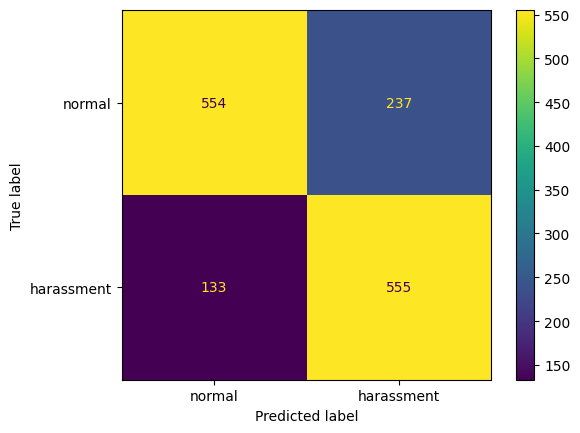

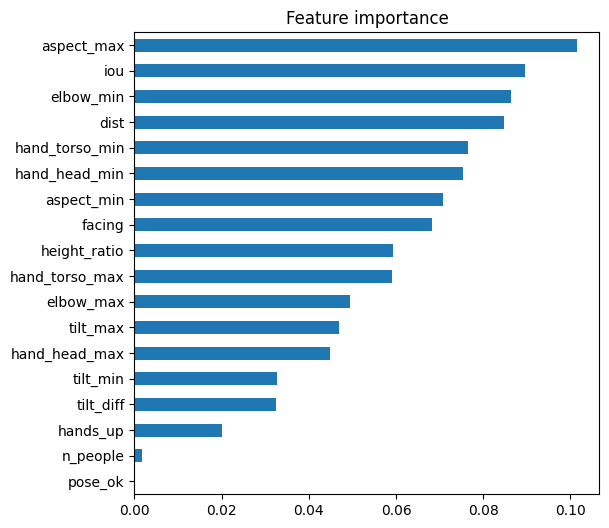

In [6]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

df = pd.read_csv("/content/output/features.csv")
if "skip" in df: df = df[df["skip"].isna()].drop(columns="skip")
print(df.label.value_counts())
FEATURES = [c for c in df.columns if c not in ("label", "group", "path")]
X, y, g = df[FEATURES].fillna(-1), df["label"], df["group"]

tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(X, y, g))
model = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=3,
                               class_weight="balanced", random_state=42, n_jobs=-1)
model.fit(X.iloc[tr], y.iloc[tr])

pred  = model.predict(X.iloc[te])
score = model.predict_proba(X.iloc[te])[:, 1]          # = harassment behavior score
print(classification_report(y.iloc[te], pred, target_names=["normal", "harassment"]))
print("ROC-AUC:", round(roc_auc_score(y.iloc[te], score), 3))
ConfusionMatrixDisplay(confusion_matrix(y.iloc[te], pred), display_labels=["normal","harassment"]).plot()
plt.show()

imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
imp.plot.barh(figsize=(6, 6), title="Feature importance"); plt.show()

## Step 6: Model save karo
Colab band hone par files ud jati hain, is liye ye cell dono files seedha download kar dega.

In [7]:
import joblib
joblib.dump({"model": model, "features": FEATURES}, "/content/output/harassment_pose_model.pkl")
print("Saved: /content/output/harassment_pose_model.pkl")
from google.colab import files
files.download("/content/output/harassment_pose_model.pkl")
files.download("/content/output/features.csv")

Saved: /content/output/harassment_pose_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 7: Kisi bhi ek image par test (ye function baad mein AIVE mein use hoga)

In [8]:
def harassment_score(image_path):
    img = cv2.imread(image_path)
    f = extract(img)
    if f is None:
        return {"score": None, "reason": "2 se kam log detect hue – pose score skip"}
    x = pd.DataFrame([f]).reindex(columns=FEATURES).fillna(-1)
    return {"score": round(float(model.predict_proba(x)[0, 1]), 3)}

print(harassment_score(df.path.iloc[0]))

{'score': 0.784}


In [9]:
import sklearn; print(sklearn.__version__)

1.6.1


In [10]:
from google.colab import files
files.download("/content/output/harassment_pose_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

train=5108  val=953  test=1492
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 25s 90ms/step - accuracy: 0.7749 - loss: 0.4897 - val_accuracy: 0.7650 - val_loss: 0.4534 - learning_rate: 0.0010
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.8532 - loss: 0.3306 - val_accuracy: 0.8930 - val_loss: 0.2535 - learning_rate: 0.0010
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.8792 - loss: 0.2836 - val_accuracy: 0.8909 - val_loss: 0.2263 - learning_rate: 0.0010
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.8925 - loss: 0.2580 - val_accuracy: 0.8982 - val_loss: 0.2596 - learning_rate: 0.0010
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.8927 - loss: 0.2503 - val_accuracy: 0.9213 - val_loss: 0.1981 - learning_rate: 0.0010
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - accuracy: 0.9033 - loss: 0.2277 - val_accuracy: 0.8814 - val_loss: 0.2596 - learning_rate: 0.0

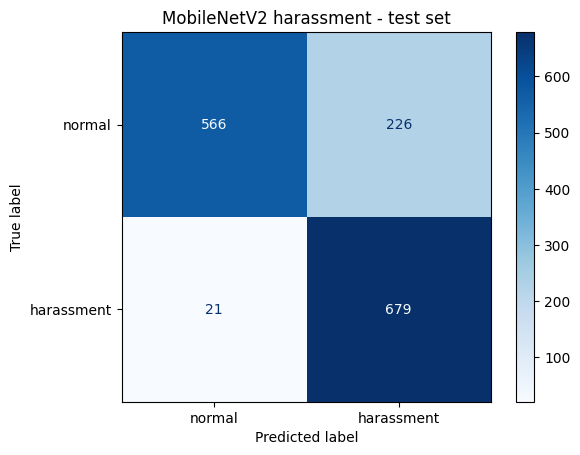

Saved artifact at '/tmp/tmpqtb030ei'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  140337822960720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140337822960912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140337822963024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140337822963216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140337822962064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140337822962640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140337822963792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140337822963600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140337822963984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140337822962256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140337822962448: Tens

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


TFLite vs Keras agreement: 100%  (90-100% hona chahiye)
TFLite size: 4.79 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# ===== Harassment: MobileNetV2 image model (app ke andar TFLite) =====
import os, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from google.colab import files

IMG, BS = 224, 32
CLASS_NAMES = ["normal", "harassment"]          # 0 = non-violent, 1 = violent
tf.random.set_seed(42)

# 1) Folder-wise split (ek video ke frames sirf ek hi taraf)
d = df_imgs.reset_index(drop=True)
trv, te = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(d, d.label, d.group))
dtv = d.iloc[trv].reset_index(drop=True)
tr, va = next(GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=7).split(dtv, dtv.label, dtv.group))
train, val, test = dtv.iloc[tr], dtv.iloc[va], d.iloc[te]
print(f"train={len(train)}  val={len(val)}  test={len(test)}")

def load(path, label):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG, IMG))
    img.set_shape((IMG, IMG, 3))
    return tf.cast(img, tf.float32), label       # 0..255, normalization model ke andar

def make_ds(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((df.path.values, df.label.values.astype("int32")))
    if shuffle: ds = ds.shuffle(len(df), seed=42)
    return ds.map(load, num_parallel_calls=tf.data.AUTOTUNE).batch(BS).prefetch(tf.data.AUTOTUNE)

train_ds, val_ds, test_ds = make_ds(train, True), make_ds(val), make_ds(test)
cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=train.label.values)
CLASS_WEIGHT = {0: cw[0], 1: cw[1]}

# 2) Model (Hamad ke model jaisa format: input 0-255, output softmax)
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.2),
], name="augmentation")
base = tf.keras.applications.MobileNetV2(input_shape=(IMG, IMG, 3), include_top=False, weights="imagenet")
base.trainable = False
inputs = tf.keras.Input(shape=(IMG, IMG, 3), name="image")
x = augment(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(2, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

cb = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
      tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, verbose=1)]

# Phase 1: sirf upar wali layers
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(train_ds, validation_data=val_ds, epochs=10, class_weight=CLASS_WEIGHT, callbacks=cb)

# Phase 2: fine-tuning (MobileNetV2 ki aakhri 30 layers)
base.trainable = True
for layer in base.layers[:-30]: layer.trainable = False
for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization): layer.trainable = False
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(train_ds, validation_data=val_ds, epochs=8, class_weight=CLASS_WEIGHT, callbacks=cb)

# 3) Test (ye images/videos model ne kabhi nahi dekhe)
y_true = test.label.values
y_prob = model.predict(test_ds, verbose=0)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))
print("ROC-AUC:", round(roc_auc_score(y_true, y_prob), 3))
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=CLASS_NAMES).plot(cmap="Blues")
plt.title("MobileNetV2 harassment - test set"); plt.show()

# 4) TFLite export + check
conv = tf.lite.TFLiteConverter.from_keras_model(model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.target_spec.supported_types = [tf.float16]
TFL = "/content/output/harassment_mobilenetv2.tflite"
open(TFL, "wb").write(conv.convert())
open("/content/output/harassment_labels.txt", "w").write("\n".join(CLASS_NAMES))

interp = tf.lite.Interpreter(model_path=TFL); interp.allocate_tensors()
inp, out = interp.get_input_details()[0], interp.get_output_details()[0]
agree = 0
for i, p in enumerate(test.path.values[:50]):
    img, _ = load(p, 0)
    interp.set_tensor(inp["index"], img.numpy()[None].astype(np.float32)); interp.invoke()
    agree += int(abs(interp.get_tensor(out["index"])[0][1] - y_prob[i]) < 0.05)
print(f"TFLite vs Keras agreement: {agree/50*100:.0f}%  (90-100% hona chahiye)")
print("TFLite size:", round(os.path.getsize(TFL) / 1e6, 2), "MB")

files.download(TFL)
files.download("/content/output/harassment_labels.txt")

In [1]:
# ===== Harassment model v2: zyada mukhtalif (diverse) data, taake naye photos par bhi sahi chale =====
!pip install -q kagglehub
import os, glob, random, cv2, numpy as np, pandas as pd, tensorflow as tf, kagglehub, matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from google.colab import files
random.seed(42); tf.random.set_seed(42)
os.makedirs("/content/output", exist_ok=True)

def find_dir(root, name):
    for r, ds, _ in os.walk(root):
        for d in ds:
            if d.lower() == name.lower(): return os.path.join(r, d)
    return None

def imgs_in(folder):
    out = []
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        out += glob.glob(os.path.join(folder, "**", ext), recursive=True)
    return sorted(out)

rows = []
# ---- (1) harassment dataset: har video-folder se har 5th frame, max 60 ----
H = kagglehub.dataset_download("tasneemhesham/harassment-dataset")
for label, name in [(1, "violent"), (0, "non-violent")]:
    base = find_dir(H, name)
    for folder in sorted(os.listdir(base)):
        ims = imgs_in(os.path.join(base, folder))
        rgb = [p for p in ims if "/rgb/" in p]
        for p in (rgb or ims)[::5][:60]:
            rows.append({"path": p, "label": label, "group": f"h_{label}_{folder}", "source": "harassment_ds"})

# ---- (2) Real Life Violence Situations: har video se 3 frames ----
R = kagglehub.dataset_download("mohamedmustafa/real-life-violence-situations-dataset")
FR = "/content/rlvs_frames"; os.makedirs(FR, exist_ok=True)
for label, name in [(1, "Violence"), (0, "NonViolence")]:
    base = find_dir(R, name)
    vids = sorted(glob.glob(os.path.join(base, "*.mp4")) + glob.glob(os.path.join(base, "*.avi")))
    print(name, len(vids), "videos")
    for v in vids:
        vid = os.path.splitext(os.path.basename(v))[0]
        outs = [f"{FR}/{name}_{vid}_{k}.jpg" for k in range(3)]
        if not all(os.path.exists(o) for o in outs):
            cap = cv2.VideoCapture(v); n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            for k, frac in enumerate((0.25, 0.5, 0.75)):
                cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, int(n * frac)))
                ok, fr = cap.read()
                if ok: cv2.imwrite(outs[k], fr)
            cap.release()
        for o in outs:
            if os.path.exists(o):
                rows.append({"path": o, "label": label, "group": f"r_{name}_{vid}", "source": "rlvs"})

# ---- (3) Intel scenes (seg_test) = normal ----
I = kagglehub.dataset_download("puneet6060/intel-image-classification")
intel = imgs_in(find_dir(I, "seg_test"))
random.shuffle(intel)
for p in intel[:1500]:
    rows.append({"path": p, "label": 0, "group": "i_" + os.path.basename(p), "source": "intel"})

df = pd.DataFrame(rows)
print(df.groupby(["source", "label"]).size())

# ---- Split: har source ke andar video/folder-wise ----
parts = {"train": [], "val": [], "test": []}
for src, d in df.groupby("source"):
    d = d.reset_index(drop=True)
    a, te = next(GroupShuffleSplit(1, test_size=0.2, random_state=42).split(d, d.label, d.group))
    da = d.iloc[a].reset_index(drop=True)
    tr, va = next(GroupShuffleSplit(1, test_size=0.15, random_state=7).split(da, da.label, da.group))
    parts["train"].append(da.iloc[tr]); parts["val"].append(da.iloc[va]); parts["test"].append(d.iloc[te])
train, val, test = (pd.concat(parts[k]).reset_index(drop=True) for k in ("train", "val", "test"))
train = train.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"train={len(train)}  val={len(val)}  test={len(test)}")

IMG, BS = 224, 32
CLASS_NAMES = ["normal", "harassment"]
def load(path, label):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG, IMG)); img.set_shape((IMG, IMG, 3))
    return tf.cast(img, tf.float32), label
def make_ds(d, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((d.path.values, d.label.values.astype("int32")))
    if shuffle: ds = ds.shuffle(len(d), seed=42)
    return ds.map(load, num_parallel_calls=tf.data.AUTOTUNE).batch(BS).prefetch(tf.data.AUTOTUNE)
train_ds, val_ds, test_ds = make_ds(train, True), make_ds(val), make_ds(test)
cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=train.label.values)
CLASS_WEIGHT = {0: cw[0], 1: cw[1]}

augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.2), tf.keras.layers.RandomContrast(0.3),
    tf.keras.layers.RandomBrightness(0.2, value_range=(0, 255)),
], name="augmentation")
base = tf.keras.applications.MobileNetV2(input_shape=(IMG, IMG, 3), include_top=False, weights="imagenet")
base.trainable = False
inputs = tf.keras.Input(shape=(IMG, IMG, 3), name="image")
x = tf.keras.applications.mobilenet_v2.preprocess_input(augment(inputs))
x = tf.keras.layers.GlobalAveragePooling2D()(base(x, training=False))
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)
model = tf.keras.Model(inputs, tf.keras.layers.Dense(2, activation="softmax")(x))
cb = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
      tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, verbose=1)]

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(train_ds, validation_data=val_ds, epochs=10, class_weight=CLASS_WEIGHT, callbacks=cb)
base.trainable = True
for layer in base.layers[:-30]: layer.trainable = False
for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization): layer.trainable = False
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(train_ds, validation_data=val_ds, epochs=8, class_weight=CLASS_WEIGHT, callbacks=cb)

# ---- Test: har source alag (sab unseen videos/photos) ----
test["prob"] = model.predict(test_ds, verbose=0)[:, 1]
test["pred"] = (test.prob >= 0.5).astype(int)
print("\n===== OVERALL =====")
print(classification_report(test.label, test.pred, target_names=CLASS_NAMES, digits=3))
print("ROC-AUC:", round(roc_auc_score(test.label, test.prob), 3))
for src, d in test.groupby("source"):
    acc = (d.label == d.pred).mean() * 100
    extra = f"  AUC={roc_auc_score(d.label, d.prob):.3f}" if d.label.nunique() == 2 else ""
    print(f"{src:14s} n={len(d):5d}  accuracy={acc:.1f}%{extra}")

# ---- TFLite export ----
conv = tf.lite.TFLiteConverter.from_keras_model(model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]; conv.target_spec.supported_types = [tf.float16]
TFL = "/content/output/harassment_mobilenetv2_v2.tflite"
open(TFL, "wb").write(conv.convert())
print("TFLite size:", round(os.path.getsize(TFL) / 1e6, 2), "MB")
files.download(TFL)

100%|██████████| 1.37G/1.37G [00:20<00:00, 70.9MB/s]

Extracting files...


100%|██████████| 3.58G/3.58G [00:46<00:00, 82.0MB/s]

Extracting files...


Violence 1000 videos
NonViolence 1000 videos
Using Colab cache for faster access to the 'intel-image-classification' dataset.
source         label
harassment_ds  0        1920
               1        2849
intel          0        1500
rlvs           0        3000
               1        3000
dtype: int64
train=8309  val=1500  test=2460
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 43s 120ms/step - accuracy: 0.7818 - loss: 0.4675 - val_accuracy: 0.8867 - val_loss: 0.3057 - learning_rate: 0.0010
Epoch 2/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - accuracy: 0.8440 - loss: 0.3452 - val_accuracy: 0.8813 - val_loss: 0.2981 - learning_rate: 0.0010
Epoch 3/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 22s 84ms/step - accuracy: 0.8638 - loss: 0.3092 - val_accuracy: 0.9040 - val_loss: 0.2435 - learning_rate: 0.0010
Epoch 4/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - accuracy: 0.8770 - loss: 0.2863 - val_accuracy: 0.9087 - val_loss: 0.2235 - learning_rate: 0.00

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>